# 손글씨 MNIST 코드 정리

코드를 구현하면서 궁금한 점도 정리

## 1. 라이브러리

In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os

`from torchvision import datasets, transforms` 의 기능 간략 소개

PyTorch 이미지 데이터를 다루기 위해 기본적으로 사용하는 두 모듈<br/>
MNIST 같은 이미지 데이터셋을 불러오고, 모델에 넣기 전에 전처리(transforms)를 적용할 때 사용합니다.

1. `datasets` : 데이터셋을 불러오는 모듈
이미 준비된 이미지 데이터셋을 쉽게 다운로드하고 로드하는 기능을 제공합니다.

- MNIST (손글씨 숫자)
- CIFAR10
- CIFAR100
- ImageNet
- FashionMNIST

    1) Stanford Cars 데이터셋도 `torchvision.datasets` 로 불러오나요?
    **가능은 하지만 보통 그렇게 하지는 않습니다.**

    torchvision에 Stanford Cars 가 존재는 합니다.<br/>
    하지만 실제 연구나 프로젝트에서는 거의 Kaggle 또는 공식 사이트 데이터를 직접 사용합니다.

    이유는 다름과 같습니다.
    1. FGVC 연구에서는 데이터 split을 직접 관리하는 경우가 많음
    2. annotation 구조를 직접 다루는 경우가 많음
    3. augmentation pipeline을 직접 설계


2. `transforms` : 데이터 전처리 모듈
이미지 데이터를 모델이 학습하기 좋은 형태로 변환하는 기능

다음과 같은 작업을 합니다.
- PIL 이미지 -> 텐서로 변환
- 정규화 (Normalization)
- 이미지 크기 변경
- 이미지 증강 (augmentation)

    1) transform 을 필터 역할 이라고 설명하는게 맞나요?
    부분적으로는 맞지만 정확한 표현은 아닙니다.

    > "주머니(Dataset)에 데이터를 집어넣고 DataLoader가 섞고(batch/shuffle) 꺼낼 때 transform 이 필터 역할

    ```bash
    Dataset
        │
        │  (index 요청)
        ▼
    Dataset.__getitem__(idx)
        │
        ▼
    이미지 로드
        │
        ▼
    transform 적용
        │
        ▼
    Tensor 반환
        │
        ▼
    DataLoader
    │
    ├ shuffle
    ├ batch
    └ worker
    ```
    transform 은 DataLoader 단계가 아니라 Dataset 내부에서 적용 됩니다.
    정확한 표현은 다음과 같습니다.
    > transform 은 Dataset 에서 데이터를 꺼낼 때 `__getitem__` 단계에서 적용 되는 **전처리 파이프라인** 입니다.


    2) `transforms.ToTensor()` 역할
    `ToTensor()`는 다음을 수행합니다.
        1. **데이터 타입 변환**
        ```bash
        PIL Image / numpy
                ↓
        torch.FloatTensor
        
        uint8 → float32 # dtype
        ```

        2. **자동 스케일링 (0~255 -> 0~1)**<br/>
        MNIST pixel : `0 ~ 255`<br/>
        변환 후 : `0.0 ~ 1.0`<br/>
        즉, `pixel / 255` 자동으로 수행됩니다.<br/>

        3. **차원 순서 변경**
        이미지 기본 구조 : `Height × Width × Channel`<br/>
        PyTorch :`Channel × Height × Width`<br/>

## 2. GPU 처리

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


## 3. train dataset 와 Test dataset

In [5]:
transform = transforms.ToTensor()
train_ds = datasets.MNIST(root='D:/data/2025/Part2/data', train=True, download=False, transform=transform)
test_ds = datasets.MNIST(root='D:/data/2025/Part2/data', train=False,download=False, transform=transform)

```bash
train_ds[0]
     │
     ▼
PIL Image load
     │
     ▼
transform(ToTensor)
     │
     ▼
Tensor (1×28×28)
```

In [9]:
print(f"Train Dataset :\n {train_ds}\n")
print(f"Test Dataset:\n {test_ds}\n")
print(f"Train Dataset Length:\n{len(train_ds)}")
print(f"Test Dataset Length:\n{len(test_ds)}")

Train Dataset :
 Dataset MNIST
    Number of datapoints: 60000
    Root location: D:/data/2025/Part2/data
    Split: Train
    StandardTransform
Transform: ToTensor()

Test Dataset:
 Dataset MNIST
    Number of datapoints: 10000
    Root location: D:/data/2025/Part2/data
    Split: Test
    StandardTransform
Transform: ToTensor()

Train Dataset Length:
60000
Test Dataset Length:
10000


In [10]:
train_ds.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [11]:
train_ds.class_to_idx # class 명 : 레이블

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

In [12]:
train_ds.data.shape

torch.Size([60000, 28, 28])

In [13]:
train_ds.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

1. `train_ds.data` 의미
MNIST Dataset 내부 구조는 다음과 같습니다.
```bash
datasets.MNIST
 ├── data    # 이미지 픽셀 데이터
 └── targets # 정답 라벨
```

2. `train_ds.data` 의 실제 Tensor 형태
```bash
torch.Size([60000, 28, 28])
# 60000 : 이미지 갯수, 28 : Height , 28: Width
```
train_ds.data[0] 은 픽셀 배열입니다.

3. 값의 범위
```bash
train_ds.data.dtype # 0 ~ 255
```
원본 픽셀 값 입니다.

4. 왜 `transform` 이 적용되지 않았는가
`transform`은 데이터를 꺼낼 때만 적용됩니다.
```bash
train_DS.data        → raw tensor
train_DS[0]          → transform 적용
```

5. MNIST 데이터 흐름

```bash
train_ds.data
(0~255 pixel)
        ↓
__getitem__()
        ↓
PIL Image 변환
        ↓
transform(ToTensor)
        ↓
float tensor
(0~1)
        ↓
model 입력
```
 1) `__getitem__` 이란
 Python 객체에서 인덱스로 데이터를 꺼낼 때 호출되는 특수 메서드입니다.
    ```python
    a = [10,20,30]
    a[0]
    ```
    리스트를 예로 들면 내부 동작은 다음과 같이 되어있습니다.
    ```python
    a.__getitem__(0)
    ```

    즉, 객체 [index]<br/>
    문법으로 객체.__getitem__(index) 을 호출합니다.<br/>

    PyTorch 의 Dataset 클래스에서도 같은 구조로 실행됩니다.
    ```python
    img, label = train_ds[0]
    train_ds.__getitem__(0)
    # Dataset[index] → __getitem__(index) 실행
    ```

 2) `__getitem__` 은 언제 호출되는가
 두 가지 경우에 호출됩니다.

        1. 직접 호출 할 때
        2. DataLoader 가 batch 만들때
        내부 동작은 다음과 같습니다.
        ```bash
        DataLoader
                ↓
        index 생성 (shuffle 가능)
                ↓
        dataset.__getitem__(index)
                ↓
        batch 구성
        ```
 3) torchvision MNIST 내부 구조
 ```bash
 MNIST Dataset
 ├── self.data # (60000, 28, 28) uint8
 ├── self.targets
 └── __getitem__()
 ```
 4) 실제 `__getitem__` 코드 흐름
 실제 torchvision MNIST 는 대략 이런 구조입니다.
 ```python
 def __getitem__(selfe, index):

        img = self.data[index]
        target = self.targets[index]

        img = Image.fromarray(img.numpy(), mode="L")

        if self.transform:
                image = self.transform(img)

        return img, target
 ```
 ```bash
 Tensor
   ↓
 numpy
   ↓
 PIL Image
   ↓
 transform
   ↓
 Tensor
 ```
 5) PIL Image 로 바꾸는 이유
 이유는 torchvision transform 이 PIL 기반으로 설계되었기 때문입니다.<br/>
 초기 torchvision transform 들은 대부분 다음 입력을 받습니다.<br/>
 ```bash
 PIL Image
 ```
 예를 들면 이렇습니다.
 ```python
 transforms.Resize()
 transforms.RandomCrop()
 transforms.RandomRotation()
 transforms.ColorJitter()
 ```
 이 transform 들은 내부적으로 PIL 연산을 사용합니다.
 따라서 입력은 PIL Image 여야 합니다.
 6) MNIST 는 데이터를 이렇게 저장합니다.
 ```bash
 Tensor(저장 효율)
 ```
 하지만 transform 은
 ```bash
 PIL Image (연산 효율)
 ```
 을 사용합니다.
 그래서 흐름은 아래와 같습니다.
 ```bass
 Dataset 저장
 Tensor
       ↓
 __getitem__
 Tensor → PIL
       ↓
 transform
       ↓
 ToTensor()
       ↓
 Tensor
 ```
 7) 전체 데이터 흐름
 MMIST 전체 파이프 라인입니다.
 ```bash
 self.data
 (0~255 uint8 tensor)

         ↓
 dataset[index]
         ↓
 __getitem__()

         ↓
 Tensor → numpy
         ↓
 PIL Image 변환

         ↓
 transform
 (ToTensor)

         ↓
 float tensor
 (0~1)

         ↓
 DataLoader
 batch 생성
 ```
 8) 최근 PyTorch 에서 Tensor 기반 transform 도 많이 추가되었습니다.
 ```python
 transforms.v2
 ```
 이 경우 Tensor → Tensor 로 바로 처리할 수 있습니다.

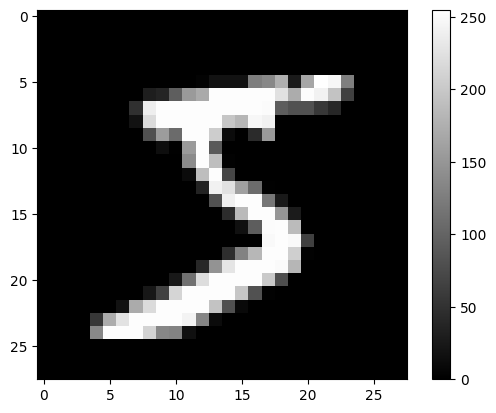

In [15]:
plt.imshow(train_ds.data[0], cmap="grey")
plt.colorbar()

In [16]:
print(train_ds.targets)
print(train_ds.targets.shape)

tensor([5, 0, 4,  ..., 5, 6, 8])
torch.Size([60000])


## DataLoader

Dataset (주머니): 데이터(이미지, 정답지 등)가 무질서하게 담겨 있는 주머니입니다.

DataLoader (관리자): 이 주머니에서 데이터를 꺼내 주는 역할을 합니다.

> "주머니(Dataset)에 데이터를 집어넣고, 섞여 있는 것을 우리가 일일이 꺼내줄 필요 없이 DataLoader가 알아서 섞고(Shuffle), 묶어서(Batch) 꺼내줍니다."

In [33]:
BATCH_SIZE = 32
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size = BATCH_SIZE, shuffle=True)

In [20]:
train_loader.dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: D:/data/2025/Part2/data
    Split: Train
    StandardTransform
Transform: ToTensor()

train dataset data type : <class 'torch.Tensor'>
train dataset data shape : torch.Size([60000, 28, 28])
train dataset data dtype : torch.uint8
train dataset data[0] :tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0, 

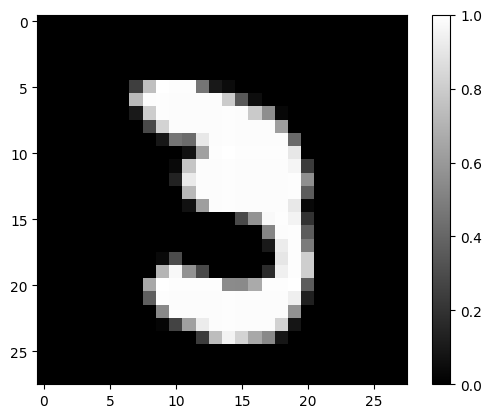

In [21]:
x_batch, y_batch = next(iter(train_loader)) # 데이터 꺼내기
print(f"train dataset data type : {type(train_ds.data)}")
print(f"train dataset data shape : {train_ds.data.shape}")
print(f"train dataset data dtype : {train_ds.data.dtype}")
print(f"train dataset data[0] :{train_ds.data[0]}")

print("="*60)
print(f"x batch dataset data type : {type(x_batch.data)}")
print(f"x batch dataset data shape : {x_batch.data.shape}")
print(f"x batch dataset data dtype : {x_batch.data.dtype}")
print(f"x batch dataset data[0] :{x_batch.data[0]}")

plt.imshow(x_batch[0].permute(1,2,0), cmap="grey")
plt.colorbar()
print(y_batch[0])

## MLP Model 만들기

In [30]:
from torch import nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fcs = nn.Sequential(nn.Linear(28*28, 100),
                                 nn.ReLU(),
                                 nn.Linear(100, 10))
        
    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = self.fcs(x)
        return x

In [34]:
# flatten 확인
x_batch, _ = next(iter(train_loader))
print(f"x batch shape : {x_batch.shape}")
flat_images = torch.flatten(x_batch)
print(f"flat_images shape : {flat_images.shape}")
flat_images2 = torch.flatten(x_batch, start_dim=1)
print(f"flat_images2 shape : {flat_images2.shape}")

x batch shape : torch.Size([32, 1, 28, 28])
flat_images shape : torch.Size([25088])
flat_images2 shape : torch.Size([32, 784])


In [35]:
model = MLP().to(DEVICE)
print(model)

x_batch , _ = next(iter(train_loader))
print(f"x batch shape : {x_batch.shape}")

model.eval()
with torch.no_grad():
    print(model(x_batch.to(DEVICE)).shape)

MLP(
  (fcs): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=10, bias=True)
  )
)
x batch shape : torch.Size([32, 1, 28, 28])
torch.Size([32, 10])


### 1. nn.Flatten()의 필요성과 데이터 차원 변화

#### 왜 Flatten 과정을 거쳐야 하는가?
`nn.Linear`(심층신경망의 Fully Connected Layer)는 입력 데이터를 1차원 벡터의 형태로 받도록 설계되어 있습니다. 하지만 컨볼루션 레이어(CNN)를 거친 데이터는 보통 `(Batch, Channel, Height, Width)`와 같은 고차원 텐서 형태를 유지합니다. 이를 선형 레이어에 통과시키기 위해서는 배치 크기를 제외한 나머지 차원을 하나의 평면으로 펼쳐주는 과정이 반드시 필요합니다.

#### nn.Linear()의 입력 Shape
`nn.Linear`에 들어오는 데이터는 기본적으로 **(배치 크기, 피처 수)** 의 2차원 구성이어야 합니다.
* **기존 데이터 (x_batch):** `(N, C, H, W)` -> [개수, 채널, 행, 열]
* **Flatten 후 데이터:** `(N, C * H * W)` -> [개수, 피처]

#### "784를 피처로 보겠다"는 의미
MNIST 데이터(28x28 이미지)를 예로 들면, 가로 28개와 세로 28개의 픽셀을 모두 펼치면 총 784개의 점이 됩니다. 이 784개 각각의 픽셀 값을 모델이 학습해야 할 독립적인 정보 단위인 **피처(Feature)**로 취급하여 입력하겠다는 뜻입니다.

#### start_dim=1 설정의 이유
`nn.Flatten(start_dim=1)`은 0번째 차원인 `배치(Batch, 데이터 개수)`는 그대로 유지하고, 1번째 차원부터 마지막 차원까지만 하나로 합치라는 명령입니다. 만약 `start_dim=0`부터 적용하면 배치 내의 모든 데이터가 하나로 섞여버려 학습이 불가능해집니다.

---

### 2. GPU 연산을 위한 데이터 및 모델 이동

#### to(DEVICE)의 역할
파이토치에서 연산을 수행할 때, 모델의 가중치(Weight)와 입력 데이터(Input Data)는 반드시 동일한 장치(Device)에 위치해야 합니다.

1.  **메모리 공간의 분리:** CPU는 시스템 메모리(RAM)를 사용하고, GPU(CUDA)는 전용 비디오 메모리(VRAM)를 사용합니다. 이들은 물리적으로 다른 공간입니다.
2.  **데이터 전송:** `x_batch.to(DEVICE)` 명령은 CPU 메모리에 있는 데이터를 GPU 메모리로 복사하여 올리는 역할을 합니다.
3.  **연산 준비:** 모델(`model.to(DEVICE)`)과 데이터가 모두 GPU로 옮겨져야만 비로소 GPU의 병렬 연산 기능을 활용하여 빠른 학습과 추론이 가능해집니다.

### 3. 모델 출력 구조의 이해: `torch.Size([32, 10])`

모델을 통과한 출력 텐서의 구조는 **[Batch Size, Class]** 형태를 가집니다.

| 차원 | 크기 | 의미 |
| :--- | :--- | :--- |
| **Batch Size** | 32 | 한 번에 처리되는 데이터의 개수 |
| **Class** | 10 | MNIST 기준 숫자 0~9까지의 분류 카테고리 |

즉, 한 개의 샘플에 대해 다음과 같은 10개의 값이 출력됩니다.
> **예시:** `tensor([ 1.2, -0.4, 0.7, 3.1, -1.0, 0.2, -0.5, 0.3, 0.8, -2.1 ])`
> 이 값들이 바로 Logit(로짓)입니다.

---

### 4. Logit(로짓) vs Probability(확률)

#### ① Logit (로짓)
확률로 변환되기 전의 `원시 점수(Raw Score)`입니다.
* **범위:** $(-\infty, +\infty)$ (음수 가능)
* **합:** 특정 값으로 정해져 있지 않음
* **특징:** 이 값만으로는 어떤 클래스가 몇 % 확률인지 직관적으로 알 수 없습니다.

#### ② 확률 (Probability)
현실적으로 해석 가능한 데이터 분포입니다.
* **범위:** $0 \leq p \leq 1$
* **합:** 모든 클래스의 확률 합은 항상 $1$
* **예시:** `[0.05, 0.02, 0.10, 0.70, 0.13]` (합 = 1)

---

### 5. Logit을 확률로 만드는 'Softmax'

로짓을 확률 분포로 변환할 때 **Softmax** 함수를 사용합니다.

$$p_i = \frac{e^{z_i}}{\sum_j e^{z_j}}$$
* $z_i$: 모델이 출력한 로짓 값
* $p_i$: 변환된 확률 값



---

### 6. 왜 PyTorch 모델 마지막에는 Softmax가 없을까?

학습 시에 사용하는 손실 함수인 `nn.CrossEntropyLoss`의 내부 구조 때문입니다.

#### ① CrossEntropyLoss의 내부 구조
PyTorch의 `CrossEntropyLoss`는 단순히 오차만 구하는 것이 아니라 다음의 과정을 하나로 합쳐놓았습니다.
> **CrossEntropyLoss = LogSoftmax + NLLLoss (Negative Log Likelihood)**

즉, 우리가 모델에서 로짓(Logit)을 그대로 내보내면, 손실 함수가 알아서 **Softmax**를 취하고 **Log**를 계산한 뒤 **Loss**를 산출합니다.

#### ② 모델에 Softmax를 직접 넣으면 발생하는 문제
만약 `nn.Sequential` 마지막에 `nn.Softmax()`를 넣고, 손실 함수로 `nn.CrossEntropyLoss`를 사용하면 **Softmax가 중복 적용**됩니다.
* **수치 안정성 감소:** 지수 함수 계산이 중복되어 값이 너무 작아지거나 커질 수 있습니다.
* **Gradient(기울기) 문제:** 학습 속도가 저하되거나 기울기 소실 문제가 발생할 수 있습니다.

---

### 7. 학습(Training) vs 추론(Inference)의 차이

| 상황 | 출력값 | 처리 방식 |
| :--- | :--- | :--- |
| **학습 시** | **Logit** | `CrossEntropyLoss`에 전달 (내부에서 Softmax 처리) |
| **추론 시** | **Logit** | 단순히 가장 큰 값을 찾을 땐 `argmax`만 사용 |
| **확률 확인 시** | **Probability** | 필요한 경우에만 `torch.softmax(logits, dim=1)` 직접 적용 |

---

### 8. [심화] MLE와 통계적 분포로 본 MSE vs CrossEntropy

분류 문제에서 왜 CrossEntropy가 MSE보다 우월한지 통계적 최적화 관점에서 정리합니다.

#### ① 최대 우도 추정(Maximum Likelihood Estimation, MLE)의 관점
딥러닝의 손실 함수는 모델이 예측하는 확률 분포와 실제 데이터 분포 사이의 거리를 최소화하는 방향으로 설계됩니다.

* **MSE와 가우시안 분포:** MSE를 최소화하는 것은 데이터의 오차가 **가우시안(정규) 분포**를 따른다고 가정하고 Likelihood를 최대화하는 것과 수학적으로 동일합니다. 주로 연속적인 수치를 예측하는 회귀(Regression)에 적합합니다.
* **CrossEntropy와 베르누이/카테고리컬 분포:** 분류 문제는 출력이 0 또는 1(혹은 여러 클래스 중 하나)인 **베르누이 분포** 혹은 **카테고리컬 분포**를 따릅니다. 이 분포에서 Likelihood를 최대화하기 위해 로그를 취하면 자연스럽게 CrossEntropy 식이 유도됩니다. 즉, 분류 문제의 본질적인 통계 특성에 더 부합하는 함수입니다.

#### ② 손실 함수 표면과 Convexity(볼록성) 문제
활성화 함수(Sigmoid/Softmax)와 손실 함수가 결합될 때 최적화 효율이 달라집니다.

* **MSE의 한계 (Non-Convex):** 분류를 위해 Sigmoid를 쓰고 MSE를 적용하면, 손실 함수의 모양이 매우 복잡하고 울퉁불퉁한 **Non-Convex** 형태가 됩니다. 특히 모델이 아주 틀린 예측을 하고 있을 때(예: 실제 1인데 0으로 예측), 기울기(Gradient)가 0에 가까워지는 '포화(Saturation)' 현상이 발생하여 학습이 멈춰버릴 수 있습니다.
* **CrossEntropy의 장점 (Convex):** 반면 CrossEntropy는 Sigmoid/Softmax의 지수 함수와 로그 함수가 서로 상쇄되도록 설계되어 있습니다. 덕분에 오차가 클수록 기울기가 더 가파르게 형성되는 **Convex**한 특성을 가지게 되어, 로컬 미니마(Local Minima)에 덜 빠지고 전역 최적점(Global Optimum)을 향해 빠르게 수렴합니다.



#### ③ 요약 비교

| 비교 항목 | MSE (Mean Squared Error) | CrossEntropy |
| :--- | :--- | :--- |
| **가정 분포** | 가우시안(정규) 분포 | 베르누이 / 카테고리컬 분포 |
| **주요 용도** | 회귀 (Regression) | 분류 (Classification) |
| **기울기 소실** | 오차가 커도 기울기가 0에 수렴 가능 | 오차가 클수록 기울기도 커짐 |
| **최적화** | Non-Convex (분류 시) | Convex (분류 시 상대적으로 유리) |

---
**결론:** 분류 문제에서는 데이터의 확률 분포 특성상 **CrossEntropy**를 사용하는 것이 통계적으로 더 타당(MLE)하며, 수학적으로도 더 매끄러운 최적화 경로를 제공합니다.

## 모델 훈련

In [ ]:
from torch import optim

# 하이퍼파라미터 설정
learning_rate = 1e-3
num_epochs = 5
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

def train_model(model, train_loader, criterion, optimizer, num_epochs):
    epoch_loss_history = []
    total_samples = len(train_loader.dataset) # 전체 학습 데이터 개수
    
    model.train() # 모델을 학습 모드로 설정
    for epoch in range(num_epochs):
        running_loss_sum = 0.0 # 에폭마다 누적 손실 초기화
        
        for x_batch, y_batch in train_loader:
            # 데이터를 지정된 장치(GPU/CPU)로 이동
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            
            # 1. 순전파 (Inference)
            predictions = model(x_batch)
            
            # 2. 손실 계산
            loss = criterion(predictions, y_batch)
            
            # 3. 역전파 및 가중치 업데이트
            optimizer.zero_grad() # 기울기(gradient)가 누적되지 않도록 초기화
            loss.backward() # 역전파를 통해 기울기 계산
            optimizer.step() # 가중치 업데이트
            
            # 4. 손실 기록
            # loss.item()은 배치 데이터의 평균 손실입니다.
            # 여기에 배치 크기를 곱해 해당 배치 전체의 손실 합을 구합니다.
            batch_total_loss = loss.item() * x_batch.shape[0]
            running_loss_sum += batch_total_loss # running loss
        
        # 에폭 마다 평균 손실 계산    
        epoch_loss = running_loss_sum/total_samples # epoch loss
        epoch_loss_history.append(epoch_loss)
        print(f"에폭(Epoch): {epoch+1}, 학습 손실(Train Loss): {epoch_loss:.4f}")
        print("-" * 50)
        
    return epoch_loss_history

### 1. 학습 필수 3단계 (Update 과정)
모델이 학습하기 위해서는 매 배치마다 다음 세 가지 명령이 세트처럼 움직여야 합니다.

1. `optimizer.zero_grad()`: 파이토치는 미분값을 계속 누적하는 성질이 있습니다. 이전 배치의 미분값이 현재 학습에 영향을 주지 않도록 매번 0으로 비워줘야 합니다.

2. `loss.backward()`: 손실 함수를 미분하여 각 가중치(Weight)가 수정되어야 할 방향과 양을 계산합니다.

3. `optimizer.step()`: 계산된 미분값을 바탕으로 실제 가중치를 업데이트합니다.

### 2. 왜 loss.item() * x_batch.shape[0]을 하나요?
마지막 배치는 설정한 배치 크기(예: 32)보다 작을 수 있습니다(예: 남은 데이터가 10개인 경우).<br/>
단순히 `loss.item()`을 모두 더해 배치 개수로 나누면, 데이터 개수가 적은 마지막 배치의 영향력이 과다하게 반영될 수 있습니다.<br/>
따라서 전체 손실의 총합을 구한 뒤, 이를 전체 데이터 개수(`total_samples`)로 나누는 것이 수학적으로 가장 정확한 평균 손실 측정 방법입니다.

에폭(Epoch): 1, 학습 손실(Train Loss): 0.0476
--------------------------------------------------
에폭(Epoch): 2, 학습 손실(Train Loss): 0.0372
--------------------------------------------------
에폭(Epoch): 3, 학습 손실(Train Loss): 0.0304
--------------------------------------------------
에폭(Epoch): 4, 학습 손실(Train Loss): 0.0257
--------------------------------------------------
에폭(Epoch): 5, 학습 손실(Train Loss): 0.0211
--------------------------------------------------


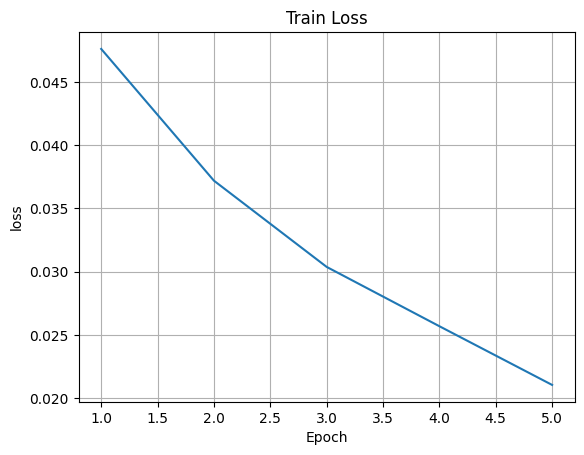

In [45]:
loss_history = train_model(model, train_loader, criterion, optimizer, num_epochs)

plt.plot(range(1,num_epochs+1),loss_history)
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("Train Loss")
plt.grid()

## Cross Entropy 확인

In [42]:
# cross entropy 구하는 여러가지 방법
import torch.nn.functional as F

# 1. 임의의 데이터 생성
# 3개의 데이터가 각각 5개의 클래스(0~4)에 대해 가지는 원시 점수(Logit)
logits = torch.randn(3,5)
print("1. 모델 출력값 (Logits):\n", logits)

# 정답 레이블 생성 (0부터 4사이의 무작위 정수 3개)
labels = torch.randint(5,(3,))
print("\n2. 정답 레이블 (Labels):\n", labels)

# ==========================================
# 방법 1: torch.nn.functional 사용 (Softmax 내장)
# ==========================================
loss_f = F.cross_entropy(logits, labels) 
print("\n[방법 1] F.cross_entropy 결과:", loss_f)

# ==========================================
# 방법 2: nn.CrossEntropyLoss 객체 사용 (Softmax 내장)
# ==========================================
criterion = nn.CrossEntropyLoss()
loss_nn = criterion(logits, labels)
print("[방법 2] nn.CrossEntropyLoss 결과:", loss_nn)

# ==========================================
# 방법 3: 수식으로 직접 계산 (Softmax -> Negative Log Likelihood)
# ==========================================
soft = nn.Softmax(dim=1)
probs = soft(logits)

# 3-2. 정답 클래스에 해당하는 확률값에 -log를 취하여 모두 더함
manual_loss_sum = 0
for i , prob in enumerate(probs): # logits가 아닌 probs(확률)를 순회해야 합니다.
    # labels[i]는 i번째 데이터의 정답 인덱스입니다.
    # prob[labels[i]]는 모델이 정답 클래스에 대해 예측한 확률값입니다.
    manual_loss_sum += -torch.log(prob[labels[i]])
    
# 3-3. 평균 손실 계산
loss_manual = manual_loss_sum / len(labels)
print("[방법 3] 직접 계산한 결과:", loss_manual)

1. 모델 출력값 (Logits):
 tensor([[ 1.0769, -0.6672,  0.0906, -0.3152,  1.7313],
        [-0.3115,  0.0834,  0.2980, -1.1442,  0.1700],
        [ 0.9320, -1.0221,  1.9437,  2.4242, -2.6063]])

2. 정답 레이블 (Labels):
 tensor([3, 1, 3])

[방법 1] F.cross_entropy 결과: tensor(1.5987)
[방법 2] nn.CrossEntropyLoss 결과: tensor(1.5987)
[방법 3] 직접 계산한 결과: tensor(1.5987)


### `torch.randint(5, (3,))`에서 `(3,)`의 의미

`torch.randint(high, size)` 함수에서 `(3,)`은 생성될 텐서의 **크기(Shape)**를 지정하는 튜플(Tuple)입니다. 

파이썬 문법에서 요소가 하나뿐인 튜플을 정의할 때는 일반 괄호 연산과 구분하기 위해 쉼표를 찍어 `(3,)`과 같이 표현합니다. 즉, 이 코드는 0부터 4까지의 무작위 정수 중 값을 뽑아 **길이가 3인 1차원 텐서(벡터)**를 생성하라는 의미입니다. 이는 3개의 데이터에 대한 정답 레이블(배치 사이즈 3)을 담기 위한 형태입니다.

## 모델 저장 & 불러오기

In [46]:
model.state_dict()

OrderedDict([('fcs.0.weight',
              tensor([[-0.0016,  0.0031,  0.0017,  ..., -0.0318,  0.0102, -0.0145],
                      [-0.0185,  0.0174, -0.0042,  ...,  0.0352,  0.0277, -0.0222],
                      [-0.0154, -0.0238, -0.0062,  ..., -0.0323, -0.0232, -0.0266],
                      ...,
                      [ 0.0053,  0.0070,  0.0091,  ..., -0.0354,  0.0025,  0.0319],
                      [ 0.0334, -0.0034,  0.0286,  ...,  0.0016, -0.0056, -0.0162],
                      [-0.0203, -0.0179,  0.0230,  ...,  0.0051,  0.0068, -0.0237]],
                     device='cuda:0')),
             ('fcs.0.bias',
              tensor([ 0.2100, -0.0524, -0.0706, -0.0715,  0.0281,  0.1672, -0.0572,  0.1202,
                       0.2423,  0.0582,  0.0700,  0.1403,  0.1206, -0.0405, -0.0324,  0.2721,
                       0.0128,  0.0011,  0.0162,  0.1193,  0.0702,  0.0736,  0.1485,  0.0658,
                       0.0473,  0.0357,  0.0676,  0.0305, -0.0613,  0.0695,  0.1727, -0.

이름, weight 값 이 쭉 들어가 있는 dict 값입니다.

In [48]:
save_model_path = "./model/MLP.pt"
os.makedirs("./model", exist_ok=True)
torch.save(model.state_dict(), save_model_path)

In [49]:
load_model = MLP().to(DEVICE)
# map_location 있어야 GPU로 학습했던 거 현재 device로 불러올 수 있습니다.
load_model.load_state_dict(torch.load(save_model_path, map_location=DEVICE))

<All keys matched successfully>

## 모델 테스트

In [50]:
def test_model(model, test_loader):
    model.eval() # 모델을 평가 모드로 전환
    
    with torch.no_grad(): # 기울기 계산 비활성화 (메모리 절약 및 연산 속도 향상)
        total_correct_predictions = 0 # 전체 정답 개수 초기화
        total_samples = len(test_loader.dataset) # 전체 테스트 데이터 개수
        
        for x_batch, y_batch in test_loader:
            # 데이터 지정된 장치 (GPU/CPU)로 이동
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            
            # 1. 추론 (Inference)
            logits = model(x_batch) # 모델을 통과한 원시 점수 출력
            
            # 2. 정답 개수 누적 계산
            # 가장 높은 값(로짓)을 가진 차원(dim=1)의 인덱스를 추출하여 예측 클래스로 사용
            predicted_classes = logits.argmax(dim=1)
            
            # 예측값과 정답이 일치하는 개수를 스칼라 값(.item()) 으로 변환하여 추출
            batch_corrects = torch.sum(predicted_classes == y_batch).item()
            total_correct_predictions += batch_corrects # 누적 정답 개수 업데이트
            
        # 최종 정확도 계산 (%)
        epoch_accuracy = (total_correct_predictions / total_samples) * 100
        
    print(f"테스트 정확도: {total_correct_predictions}/{total_samples} ({epoch_accuracy:.1f} %)")
    return round(epoch_accuracy, 1)
        

In [51]:
test_model(load_model, test_loader)

테스트 정확도: 9723/10000 (97.2 %)


97.2

### 1. Softmax 통과 전후로 대소 관계가 바뀌지 않는 이유

**질문:** `logits`(원시 점수)는 Softmax 통과 직전 값인데, 왜 이 값으로 바로 비교를 해도 상관이 없으며 순서가 바뀌지 않습니까?

**해답:** Softmax 함수는 입력값에 지수 함수($e^x$)를 취합니다. 지수 함수는 입력값 $x$가 커지면 출력값도 무조건 커지는 **단조 증가(Monotonically Increasing)** 성질을 가지고 있습니다. 
따라서 `logits` 상태에서 가장 컸던 값은 Softmax를 통과하여 0~1 사이의 확률로 변환되더라도 여전히 가장 큰 값을 유지합니다. 단순히 '어떤 숫자가 1등인지' 순위만 판별할 목적이라면, 굳이 연산량을 늘려가며 Softmax를 거칠 필요 없이 `logits` 값을 그대로 비교하는 것이 훨씬 효율적입니다.

---

### 2. 노드 중에서 가장 큰 값을 레이블로 정한다는 의미와 argmax의 연관성

**질문:** 노드 중에서 가장 큰 값을 가지는 노드를 레이블로 정한다는 것은 무슨 말이며, `argmax`와는 어떤 연관이 있습니까?

**해답:** 모델은 하나의 이미지에 대해 0부터 9까지 총 10개의 숫자(클래스)에 대한 각각의 점수를 노드로 출력합니다. 
이때 우리가 최종적으로 알고 싶은 것은 '가장 높은 점수 값 자체(예: 8.5점)'가 아니라, '그 점수를 받은 과목의 이름(예: 숫자 7)'입니다. 
`argmax(dim=1)` 함수는 텐서 내부에서 가장 큰 숫자의 **인덱스(위치 번호)**를 반환하는 함수입니다. 따라서 10개의 노드 점수 중 가장 큰 점수가 위치한 인덱스를 추출하면, 그것이 바로 모델이 최종적으로 예측한 레이블(`predicted_classes`)이 됩니다.



---

#### 3. 예측 결과가 32개의 숫자로 나오는 이유

**질문:** `logits`의 차원이 `[32, 10]`인데, `argmax`를 통과한 예측 결과(`predicted_classes`)를 출력해보면 왜 32개의 숫자가 나옵니까? 10개 중에서 가장 큰 노드를 고르는 것이 아닙니까?

**해답:** `[32, 10]`이라는 차원은 **32장의 이미지** 각각에 대해 **10개의 클래스 점수**가 매겨져 있다는 뜻입니다.
우리는 `argmax(dim=1)`을 통해 '각 이미지마다' 10개의 점수 중 1등 인덱스를 하나씩 뽑아냅니다. 첫 번째 이미지에서 1등 번호 1개, 두 번째 이미지에서 1등 번호 1개, 이런 식으로 32장의 이미지 전체에 대해 연산을 수행하기 때문에 최종적으로 도출되는 예측 번호(`predicted_classes`) 역시 정확히 32개가 되는 것입니다.

---

### 4. batch_corrects 계산과 y_batch가 정답인 이유

**질문:** `batch_corrects = torch.sum(predicted_classes == y_batch).item()` 코드는 무엇을 의미하며, 왜 `y_batch`가 정답입니까?

**해답:** 지도 학습(Supervised Learning)에서 데이터로더가 반환하는 `x_batch`는 모델이 풀어야 할 '문제(이미지)'이고, `y_batch`는 사람이 미리 달아놓은 '실제 정답지(레이블)'입니다.
`predicted_classes`에는 모델이 방금 32개의 이미지에 대해 나름대로 예측하여 내놓은 답안이 들어있습니다. 
따라서 `predicted_classes == y_batch` 연산은 모델의 답안지 32개와 실제 정답지 32개를 나란히 놓고 채점하는 과정입니다. 여기서 일치하는(True) 개수를 `torch.sum()`으로 모두 더한 뒤 `.item()`으로 순수 숫자만 뽑아낸 것이 바로 해당 배치에서의 총 정답 개수, 즉 `batch_corrects`가 됩니다.

In [52]:
def visualize_predictions(model, test_loader):
    model.eval() # 모델을 평가 모드로 전환
    
    with torch.no_grad():
        x_batch, y_batch = next(iter(test_loader))
        x_batch_device = x_batch.to(DEVICE)
        
        # 1. 추론을 통해 원시 점수 (Logit) 획득
        logits = model(x_batch_device)
        
        # 2. 가장 높은 점수의 인덱스를 찾아 예측 클래스로 지정
        predicted_classes = logits.argmax(dim=1)
    
    # Matplotlib은 CPU 메모리의 데이터만 그릴 수 있으므로 텐서를 CPU로 다시 이동
    x_batch_cpu = x_batch.to("cpu")
    
    plt.figure(figsize=(8,4))
    
    # 배치 데이터 중 처음 6개의 이미지 반복하여 시각화
    for idx in range(6):
        # 2행 3열 격자 구조에서 서브 플롯 생성
        plt.subplot(2, 3, idx+1, xticks=[] , yticks=[])
        
        # PyTorch 의 이미지 형태 [채널, 높이, 너비] 를
        # Matplotlib이 인식하는 [높이, 너비, 채널] 형태로 축 순서 변경
        plt.imshow(x_batch_cpu[idx].permute(1,2,0), cmap="grey")
        
        # 인덱스 번호(예: 0)를 실제 데이터셋의 클래스 이름으로 변환
        predicted_label_name = test_loader.dataset.classes[predicted_classes[idx]]
        true_label_name = test_loader.dataset.classes[y_batch[idx]]
        
        # 예측값과 실제 정답이 일치하면 초록색, 틀리면 빨간색으로 설정
        text_color = "g" if predicted_label_name == true_label_name else "r"
        
        # 이미지 위에 '예측값 (실제값)' 형태로 제목 출력
        plt.title(f"{predicted_label_name} ({true_label_name})", color=text_color)
        
    plt.show()

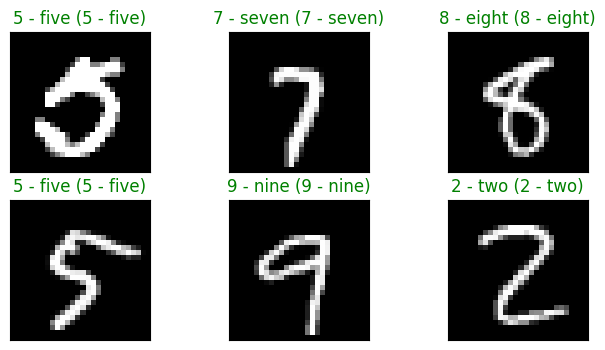

In [55]:
visualize_predictions(model, test_loader)

#### 1. `next(iter(test_loader))` 의 의미

전체 테스트 데이터를 반복(For문)하여 모두 그릴 필요 없이, 시각화 용도로 **단 하나의 배치(Batch)**만 꺼내오기 위해 파이썬 내장 함수인 `iter()`(반복자 생성)와 `next()`(다음 값 호출)를 사용했습니다.

#### 2. 왜 `to("cpu")`가 필요한가?

파이토치의 텐서가 GPU 메모리에 올라가 있을 경우, 파이썬의 대표적인 시각화 라이브러리인 Matplotlib은 이 데이터에 직접 접근하여 그림을 그릴 수 없습니다. 따라서 연산이 끝난 후 화면에 출력할 이미지 데이터는 반드시 시스템의 메인 메모리(CPU)로 다시 내려주어야 합니다.

#### 3. `permute(1, 2, 0)` 의 역할

* **PyTorch 텐서 구조:** `[Channel, Height, Width]` (예: 컬러 이미지면 `[3, 28, 28]`)
* **Matplotlib 요구 구조:** `[Height, Width, Channel]` (예: `[28, 28, 3]`)
이처럼 두 라이브러리가 다루는 차원의 순서가 다르기 때문에, `permute` 함수를 사용하여 0번 축(Channel)을 맨 뒤인 2번 위치로 보내고, 1번(Height)과 2번(Width) 축을 앞으로 당겨오는 형태 변환을 수행해야 정상적인 이미지가 출력됩니다.

In [56]:
# 파라미터 수 구하기
def count_params(model):
    num = sum([p.numel() for p in model.parameters() if p.requires_grad])
    return num

In [57]:
print(count_params(load_model))

79510


## confusion matrix

In [60]:
def get_confusion_matrix(model, test_loader):
    # 데이터셋에 정의된 전체 클래스의 개수
    num_classes = len(test_loader.dataset.classes)
    
    model.eval()
    with torch.no_grad():
        # 클래스 개수 x 클래스 개수 크기의 영행렬(0으로 채워진 텐서) 생성
        confusion = torch.zeros(num_classes, num_classes)
        
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            
            # 1. 추론 (Inference)
            logits = model(x_batch)
            
            # 2. 예측 클래스 추출 (가장 높은 로짓 값의 인덱스)
            predicted_classes = logits.argmax(dim=1)

            # 3. 혼동 행렬 업데이트를 위한 1차원 인덱스 계산
            # 정답(y_batch)을 행으로, 예측값(predicted_classes)을 열로 매핑합니다.
            flat_indices = num_classes * y_batch.cpu() + predicted_classes.cpu()
            
            # 4. 각 인덱스의 등장 빈도수(bincount) 계산 및 2차원 재배열
            # minlength=num_classes**2 설정: 
            # 배치 내에 후순위 클래스(예: 숫자 9)에 대한 예측/정답이 아예 없더라도,
            # 출력 배열의 길이가 항상 전체 원소 개수(예: 100)로 고정되게 만듭니다.
            bincount_result = torch.bincount(flat_indices, minlength=num_classes**2)
            confusion += bincount_result.reshape(num_classes, num_classes)
            
    # 행렬 시각화 라이브러리(Scikit-learn, Seaborn 등)와의 호환성을 위해 NumPy 배열로 변환
    return confusion.numpy()

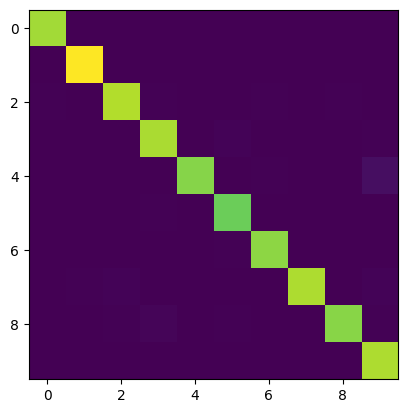

In [61]:
confusion = get_confusion_matrix(load_model, test_loader)
plt.imshow(confusion)

### 핵심 개념 설명: 1차원 `bincount`를 활용한 2차원 매핑 원리

가장 헷갈리기 쉬운 `num_classes * y_batch + predicted_classes` 연산의 의미를 짚어보겠습니다.
이 연산은 2차원 표(행과 열)의 특정 위치를 1차원 배열의 인덱스(순서)로 변환하는 기법입니다.

**예시 상황 (클래스 개수가 10개인 경우):**

* `y_batch` (실제 정답) = 2
* `predicted_classes` (모델의 예측) = 3

위 데이터는 혼동 행렬의 **[2번 행, 3번 열]** 위치에 카운트가 1 증가해야 한다는 의미입니다.
이를 파이토치의 1차원 함수인 `torch.bincount`로 처리하기 위해 하나의 숫자로 만듭니다.

> $10 \times 2 (\text{정답}) + 3 (\text{예측}) = 23$

즉, 100칸짜리 1차원 배열(0~99번 인덱스)에서 **23번 인덱스**에 해당하는 값의 빈도를 1 올립니다.
모든 배치의 계산이 끝난 후 이 100칸짜리 1차원 배열을 `reshape(10, 10)`을 통해 다시 10행 10열로 접어주면, 우리가 원하던 2차원 혼동 행렬의 모습이 완벽하게 복원됩니다.

In [66]:
import numpy as np

def plot_confusion_matrix(confusion_matrix, class_names=None):
    # 행렬의 행 개수를 통해 전체 클래스의 개수를 파악합니다.
    num_classes = confusion_matrix.shape[0]
    
    # 1. 정확도 계산 (np.trace 활용)
    # np.trace는 행렬의 대각선 성분(행과 열의 인덱스가 같은 값)을 모두 더하는 함수입니다.
    # 혼동 행렬에서 대각선 성분은 예측값과 실제값이 일치한 '정답 개수'를 의미합니다.
    total_correct = np.trace(confusion_matrix)
    total_samples = np.sum(confusion_matrix)
    accuracy = (total_correct / total_samples) * 100

    # 2. 그래프 기본 설정
    plt.figure(figsize=(10, 7))
    plt.imshow(confusion_matrix, cmap="Blues") # 파란색 계열의 히트맵 색상 적용
    plt.title("Confusion Matrix")
    plt.colorbar() # 우측에 색상별 수치를 나타내는 컬러바 추가

    # 3. 행렬 내부 텍스트 표기
    for row in range(num_classes):
        for col in range(num_classes):
            # 배경색 대비 가독성을 위한 글자색 자동 조절 로직
            # 행렬 내 최대값의 1.5분의 1보다 큰 값(배경이 짙은 파란색)에는 흰색 글씨를,
            # 작은 값(배경이 밝은 색)에는 검은색 글씨를 적용합니다.
            threshold = np.max(confusion_matrix) / 1.5
            text_color = "white" if confusion_matrix[row, col] > threshold else "black"
            
            # plt.text는 (x좌표, y좌표, 텍스트) 순서로 입력받습니다.
            # 행렬의 열(col)이 x축, 행(row)이 y축에 해당합니다.
            plt.text(col, row, round(confusion_matrix[row, col]),
                     horizontalalignment="center", fontsize=10, color=text_color)

    # 4. 축 눈금 및 라벨 설정
    if class_names is not None:
        plt.xticks(range(num_classes), class_names)
        plt.yticks(range(num_classes), class_names)
    else:
        plt.xticks(range(num_classes))
        plt.yticks(range(num_classes))

    # x축 아래에 예측 라벨과 함께 계산된 전체 정확도를 출력합니다.
    plt.xlabel(f"Predicted Label \n Accuracy = {accuracy:.1f} %")
    plt.ylabel("True Label")

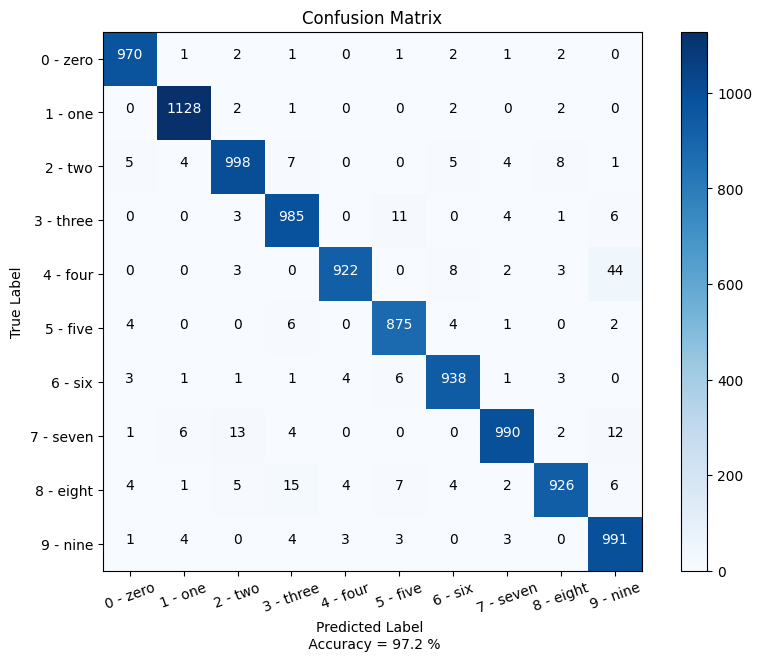

In [67]:
confusion = get_confusion_matrix(load_model, test_loader)
plot_confusion_matrix(confusion, test_ds.classes)
plt.xticks(rotation=20);

`plt.xticks(rotation=20);` 에서 세미콜론이 있을 때 (;):<br/>
마지막 줄의 반환값을 화면에 텍스트로 출력하는 것을 강제로 숨김(Suppress) 처리합니다.<br/>
따라서 불필요한 텍스트 찌꺼기 없이 깔끔하게 시각화된 그래프만 화면에 띄울 수 있습니다.